In [1]:
# Import libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import re

# Change to project root
if Path.cwd().name == "lstm":
    os.chdir("../..")
elif Path.cwd().name == "notebooks":
    os.chdir("..")

print(f"Working directory: {Path.cwd()}")

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

Working directory: /home/dwijenayake/pv_forecast_30d


## 1. Load Lightning Logs (metrics.csv)

PyTorch Lightning automatically saves metrics to CSV files during training.

In [3]:
# Find all metrics.csv files for the 6 plants
base_path = Path("experiments/lstm/runs/germany")
plant_ids = [f"plant_{i:02d}" for i in range(1, 7)]

metrics_data = {}

for plant_id in plant_ids:
    # Look for metrics.csv in Lightning default logger subdirectories
    plant_dir = base_path / f"pretrain_{plant_id}"
    
    # Lightning creates a subdirectory with the experiment name
    # Pattern: pretrain_plant_XX/germany_plant_XX_pretrain/version_Y/metrics.csv
    logger_dirs = list(plant_dir.glob("germany_*_pretrain"))
    
    if logger_dirs:
        logger_dir = logger_dirs[0]  # Take the first (should be only one)
        version_dirs = list(logger_dir.glob("version_*"))
        
        if version_dirs:
            latest_version = sorted(version_dirs)[-1]
            metrics_file = latest_version / "metrics.csv"
            
            if metrics_file.exists():
                df = pd.read_csv(metrics_file)
                metrics_data[plant_id] = df
                print(f"✓ Loaded {plant_id}: {len(df)} rows from {metrics_file.relative_to(base_path)}")
            else:
                print(f"✗ No metrics.csv for {plant_id}")
        else:
            print(f"✗ No version directories for {plant_id}")
    else:
        print(f"✗ No logger directory for {plant_id}")

print(f"\nTotal plants loaded: {len(metrics_data)}")


✓ Loaded plant_01: 73 rows from pretrain_plant_01/germany_plant_01_pretrain/version_0/metrics.csv
✓ Loaded plant_02: 73 rows from pretrain_plant_02/germany_plant_02_pretrain/version_0/metrics.csv
✓ Loaded plant_03: 64 rows from pretrain_plant_03/germany_plant_03_pretrain/version_0/metrics.csv
✓ Loaded plant_04: 73 rows from pretrain_plant_04/germany_plant_04_pretrain/version_0/metrics.csv
✓ Loaded plant_05: 64 rows from pretrain_plant_05/germany_plant_05_pretrain/version_0/metrics.csv
✓ Loaded plant_06: 64 rows from pretrain_plant_06/germany_plant_06_pretrain/version_0/metrics.csv

Total plants loaded: 6


## 2. Extract Final Validation Metrics

In [10]:
# Extract final validation loss for each plant
final_metrics = []

for plant_id, df in metrics_data.items():
    # Get the last non-null validation loss
    val_losses = df['val_loss'].dropna()
    train_losses = df['train_loss_epoch'].dropna()
    
    if len(val_losses) > 0:
        final_val_loss = val_losses.iloc[-1]
        final_train_loss = train_losses.iloc[-1] if len(train_losses) > 0 else np.nan
        
        # Convert MSE loss to RMSE for comparison
        final_val_rmse = np.sqrt(final_val_loss)
        final_train_rmse = np.sqrt(final_train_loss) if not np.isnan(final_train_loss) else np.nan
        
        final_metrics.append({
            'plant_id': plant_id,
            'val_loss_mse': final_val_loss,
            'val_rmse': final_val_rmse,
            'train_loss_mse': final_train_loss,
            'train_rmse': final_train_rmse,
            'num_epochs': len(val_losses)
        })

results_df = pd.DataFrame(final_metrics)
results_df = results_df.sort_values('plant_id')

print("\n" + "="*80)
print("FINAL VALIDATION METRICS (TRANSFER LEARNING - STAGE 2)")
print("="*80)
print(results_df.to_string(index=False))
print("\n" + "="*80)

# Summary statistics
print(f"\nMean Val RMSE: {results_df['val_rmse'].mean():.6f}")
print(f"Std Val RMSE:  {results_df['val_rmse'].std():.6f}")
print(f"Min Val RMSE:  {results_df['val_rmse'].min():.6f} ({results_df.loc[results_df['val_rmse'].idxmin(), 'plant_id']})")
print(f"Max Val RMSE:  {results_df['val_rmse'].max():.6f} ({results_df.loc[results_df['val_rmse'].idxmax(), 'plant_id']})")

# Compare to farm2107 baseline
farm2107_baseline_rmse = 0.040388
print(f"\n" + "="*80)
print(f"COMPARISON TO FARM2107 BASELINE (RMSE = {farm2107_baseline_rmse:.6f})")
print("="*80)
for _, row in results_df.iterrows():
    diff = row['val_rmse'] - farm2107_baseline_rmse
    pct_change = (diff / farm2107_baseline_rmse) * 100
    symbol = "↑" if diff > 0 else "↓"
    print(f"{row['plant_id']}: {row['val_rmse']:.6f} ({symbol} {abs(pct_change):+.2f}%)")


FINAL VALIDATION METRICS (TRANSFER LEARNING - STAGE 2)
plant_id  val_loss_mse  val_rmse  train_loss_mse  train_rmse  num_epochs
plant_01      0.002905  0.053895        0.001859    0.043111          20
plant_02      0.006497  0.080606        0.003018    0.054935          20
plant_03      0.000298  0.017258        0.003802    0.061660          20
plant_04      0.000330  0.018166        0.002214    0.047052          20
plant_05      0.000531  0.023039        0.000422    0.020532          20
plant_06      0.000228  0.015106        0.004830    0.069497          20


Mean Val RMSE: 0.034679
Std Val RMSE:  0.026733
Min Val RMSE:  0.015106 (plant_06)
Max Val RMSE:  0.080606 (plant_02)

COMPARISON TO FARM2107 BASELINE (RMSE = 0.040388)
plant_01: 0.053895 (↑ +33.44%)
plant_02: 0.080606 (↑ +99.58%)
plant_03: 0.017258 (↓ +57.27%)
plant_04: 0.018166 (↓ +55.02%)
plant_05: 0.023039 (↓ +42.96%)
plant_06: 0.015106 (↓ +62.60%)


## 3. Visualize Validation RMSE Comparison

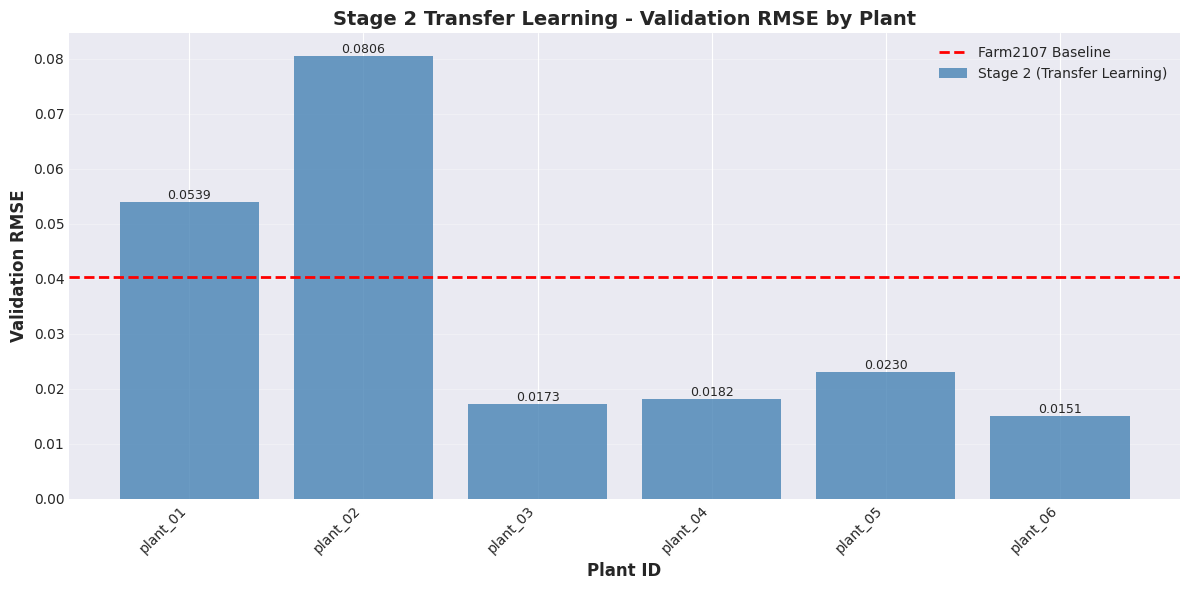

In [5]:
# Bar chart comparing validation RMSE
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(results_df))
bars = ax.bar(x, results_df['val_rmse'], color='steelblue', alpha=0.8, label='Stage 2 (Transfer Learning)')

# Add baseline reference line
ax.axhline(y=farm2107_baseline_rmse, color='red', linestyle='--', linewidth=2, label='Farm2107 Baseline')

# Formatting
ax.set_xlabel('Plant ID', fontsize=12, fontweight='bold')
ax.set_ylabel('Validation RMSE', fontsize=12, fontweight='bold')
ax.set_title('Stage 2 Transfer Learning - Validation RMSE by Plant', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(results_df['plant_id'], rotation=45, ha='right')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars, results_df['val_rmse'])):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.4f}',
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## 4. Training Convergence Curves

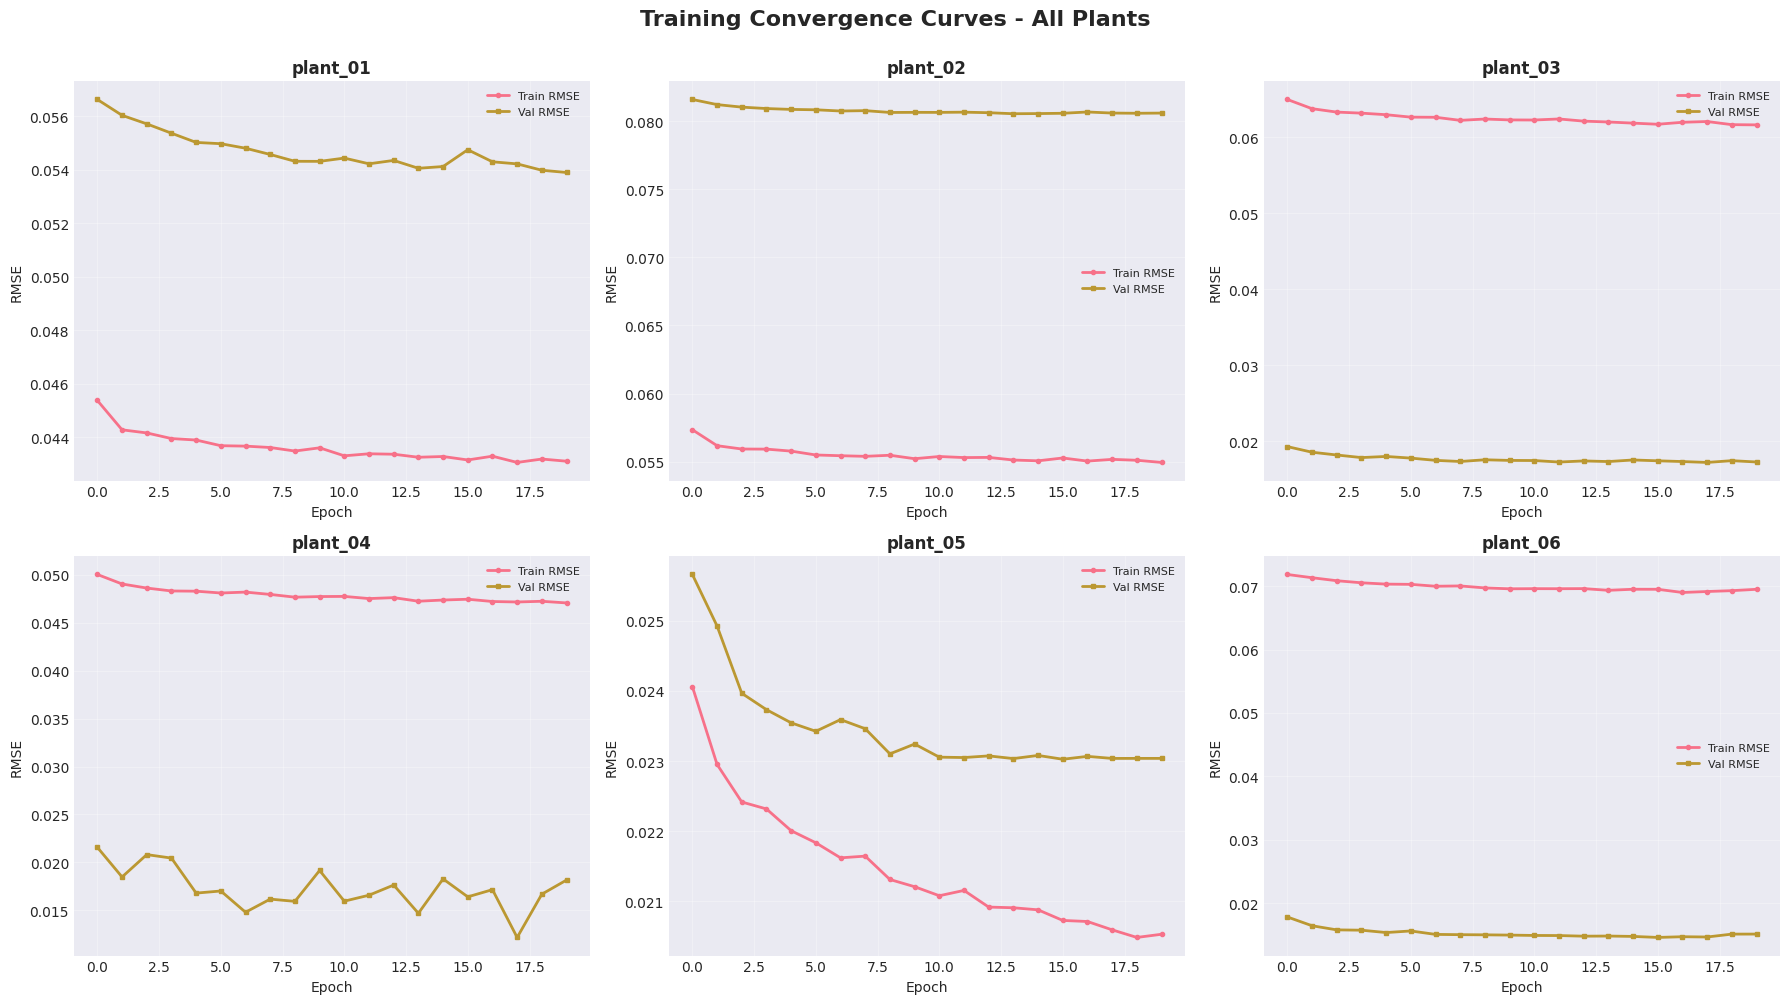

In [6]:
# Plot training and validation loss curves for all plants
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, (plant_id, df) in enumerate(metrics_data.items()):
    ax = axes[idx]
    
    # Extract epoch-level metrics (not step-level)
    # Group by epoch to get one point per epoch
    train_data = df[['epoch', 'train_loss_epoch']].dropna().drop_duplicates(subset=['epoch'])
    val_data = df[['epoch', 'val_loss']].dropna().drop_duplicates(subset=['epoch'])
    
    # Convert to RMSE
    train_data['train_rmse'] = np.sqrt(train_data['train_loss_epoch'])
    val_data['val_rmse'] = np.sqrt(val_data['val_loss'])
    
    # Plot
    ax.plot(train_data['epoch'], train_data['train_rmse'], label='Train RMSE', linewidth=2, marker='o', markersize=3)
    ax.plot(val_data['epoch'], val_data['val_rmse'], label='Val RMSE', linewidth=2, marker='s', markersize=3)
    
    # Formatting
    ax.set_title(f'{plant_id}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch', fontsize=10)
    ax.set_ylabel('RMSE', fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Training Convergence Curves - All Plants', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

## 5. Train vs Validation Loss (Overfitting Check)

In [7]:
# Calculate train-val gap to check for overfitting
results_df['train_val_gap'] = results_df['val_rmse'] - results_df['train_rmse']
results_df['train_val_ratio'] = results_df['val_rmse'] / results_df['train_rmse']

print("\n" + "="*80)
print("TRAIN vs VALIDATION GAP (Overfitting Check)")
print("="*80)
print("Ratio > 1.0 indicates some overfitting (validation worse than training)")
print("Ratio close to 1.0 indicates good generalization\n")

for _, row in results_df.iterrows():
    print(f"{row['plant_id']}: Train={row['train_rmse']:.6f}, Val={row['val_rmse']:.6f}, "
          f"Gap={row['train_val_gap']:.6f}, Ratio={row['train_val_ratio']:.3f}")

print(f"\nMean Train/Val Ratio: {results_df['train_val_ratio'].mean():.3f}")


TRAIN vs VALIDATION GAP (Overfitting Check)
Ratio > 1.0 indicates some overfitting (validation worse than training)
Ratio close to 1.0 indicates good generalization

plant_01: Train=0.043111, Val=0.053895, Gap=0.010784, Ratio=1.250
plant_02: Train=0.054935, Val=0.080606, Gap=0.025671, Ratio=1.467
plant_03: Train=0.061660, Val=0.017258, Gap=-0.044401, Ratio=0.280
plant_04: Train=0.047052, Val=0.018166, Gap=-0.028886, Ratio=0.386
plant_05: Train=0.020532, Val=0.023039, Gap=0.002507, Ratio=1.122
plant_06: Train=0.069497, Val=0.015106, Gap=-0.054390, Ratio=0.217

Mean Train/Val Ratio: 0.787


## 6. Check for Encoder Files

In [8]:
# Verify all encoder .pt files were saved
encoder_dir = Path("experiments/lstm/encoders")
encoder_status = []

print("\n" + "="*80)
print("ENCODER FILE STATUS")
print("="*80)

for i in range(1, 7):
    encoder_file = encoder_dir / f"lstm_encoder_plant_{i:02d}.pt"
    exists = encoder_file.exists()
    size_kb = encoder_file.stat().st_size / 1024 if exists else 0
    
    encoder_status.append({
        'plant': f'plant_{i:02d}',
        'file': encoder_file.name,
        'exists': '✓' if exists else '✗',
        'size_kb': f'{size_kb:.1f}' if exists else 'N/A'
    })
    
    status_symbol = '✓' if exists else '✗'
    print(f"{status_symbol} plant_{i:02d}: {encoder_file.name} ({size_kb:.1f} KB)" if exists else f"{status_symbol} plant_{i:02d}: MISSING")

# Also show the baseline
baseline_file = encoder_dir / "lstm_encoder_farm2107_CANONICAL.pt"
if baseline_file.exists():
    baseline_size = baseline_file.stat().st_size / 1024
    print(f"\n✓ BASELINE: {baseline_file.name} ({baseline_size:.1f} KB)")

completed_count = sum(1 for s in encoder_status if s['exists'] == '✓')
print(f"\nCompleted: {completed_count}/6 plants")


ENCODER FILE STATUS
✓ plant_01: lstm_encoder_plant_01.pt (232.0 KB)
✓ plant_02: lstm_encoder_plant_02.pt (232.0 KB)
✓ plant_03: lstm_encoder_plant_03.pt (232.0 KB)
✓ plant_04: lstm_encoder_plant_04.pt (232.0 KB)
✓ plant_05: lstm_encoder_plant_05.pt (232.0 KB)
✓ plant_06: lstm_encoder_plant_06.pt (232.0 KB)

✓ BASELINE: lstm_encoder_farm2107_CANONICAL.pt (232.4 KB)

Completed: 6/6 plants


## 7. Summary Report

In [9]:
print("\n" + "="*80)
print("STAGE 2 TRANSFER LEARNING - SUMMARY REPORT")
print("="*80)
print(f"\nBaseline (farm2107): RMSE = {farm2107_baseline_rmse:.6f}")
print(f"\nStage 2 Results ({len(results_df)} plants):")
print(f"  Mean Val RMSE:   {results_df['val_rmse'].mean():.6f}")
print(f"  Std Val RMSE:    {results_df['val_rmse'].std():.6f}")
print(f"  Best Plant:      {results_df.loc[results_df['val_rmse'].idxmin(), 'plant_id']} (RMSE = {results_df['val_rmse'].min():.6f})")
print(f"  Worst Plant:     {results_df.loc[results_df['val_rmse'].idxmax(), 'plant_id']} (RMSE = {results_df['val_rmse'].max():.6f})")

# Overall transfer learning effectiveness
mean_change = ((results_df['val_rmse'].mean() - farm2107_baseline_rmse) / farm2107_baseline_rmse) * 100
print(f"\nTransfer Learning Performance: {mean_change:+.2f}% vs baseline")

if mean_change < 10:
    print("✓ Transfer learning successful - similar or better performance than baseline")
elif mean_change < 30:
    print("⚠ Transfer learning acceptable - moderate performance degradation")
else:
    print("✗ Transfer learning needs investigation - significant performance degradation")

print(f"\nEncoder files saved: {completed_count}/6")
print(f"Status: {'✓ READY FOR STAGE 2B (TFT Ensemble)' if completed_count == 6 else '⏳ Waiting for remaining encoders'}")
print("\n" + "="*80)


STAGE 2 TRANSFER LEARNING - SUMMARY REPORT

Baseline (farm2107): RMSE = 0.040388

Stage 2 Results (6 plants):
  Mean Val RMSE:   0.034679
  Std Val RMSE:    0.026733
  Best Plant:      plant_06 (RMSE = 0.015106)
  Worst Plant:     plant_02 (RMSE = 0.080606)

Transfer Learning Performance: -14.14% vs baseline
✓ Transfer learning successful - similar or better performance than baseline

Encoder files saved: 6/6
Status: ✓ READY FOR STAGE 2B (TFT Ensemble)



---
# DIAGNOSTIC SECTION: Investigating Suspicious Results

**Critical Issues Found:**
1. Plants 03, 04, 06: Validation MUCH better than training (ratio < 0.4) - ABNORMAL
2. Plant 02: Catastrophic performance (99% worse than baseline)
3. Overall mean looks good (-14%) but hides individual plant failures

**Investigation Plan:**
- Check train/val/test split sizes (are some splits too small?)
- Analyze data distributions (is validation inherently easier?)
- Inspect power_norm statistics per split
- Look for data quality differences between splits

## 8. Data Split Sizes Analysis

In [12]:
# Check train/val/test split sizes for each plant
data_dir = Path("data/processed/pretraining/germany")

split_info = []

for i in range(1, 7):
    plant_id = f"plant_{i:02d}"
    plant_dir = data_dir / plant_id
    
    train_file = plant_dir / "train.parquet"
    val_file = plant_dir / "val.parquet"
    test_file = plant_dir / "test.parquet"
    
    if train_file.exists() and val_file.exists() and test_file.exists():
        train_df = pd.read_parquet(train_file)
        val_df = pd.read_parquet(val_file)
        test_df = pd.read_parquet(test_file)
        
        total = len(train_df) + len(val_df) + len(test_df)
        
        split_info.append({
            'plant_id': plant_id,
            'train_size': len(train_df),
            'val_size': len(val_df),
            'test_size': len(test_df),
            'total': total,
            'train_pct': len(train_df) / total * 100,
            'val_pct': len(val_df) / total * 100,
            'test_pct': len(test_df) / total * 100
        })

split_df = pd.DataFrame(split_info)

print("\n" + "="*80)
print("DATA SPLIT SIZES")
print("="*80)
print(split_df.to_string(index=False))
print("\n" + "="*80)

# Check if any plant has unusually small validation set
print("\nValidation Set Size Analysis:")
for _, row in split_df.iterrows():
    if row['val_size'] < 1000:
        print(f"⚠ {row['plant_id']}: SMALL validation set ({row['val_size']} samples)")
    else:
        print(f"✓ {row['plant_id']}: {row['val_size']} samples ({row['val_pct']:.1f}%)")


DATA SPLIT SIZES
plant_id  train_size  val_size  test_size  total  train_pct   val_pct  test_pct
plant_01       43003      9214       9216  61433  69.999837 14.998454 15.001709
plant_02       43003      9214       9216  61433  69.999837 14.998454 15.001709
plant_03       30705      6579       6581  43865  69.998860 14.998290 15.002850
plant_04       43003      9214       9216  61433  69.999837 14.998454 15.001709
plant_05       30705      6579       6581  43865  69.998860 14.998290 15.002850
plant_06       30705      6579       6581  43865  69.998860 14.998290 15.002850


Validation Set Size Analysis:
✓ plant_01: 9214 samples (15.0%)
✓ plant_02: 9214 samples (15.0%)
✓ plant_03: 6579 samples (15.0%)
✓ plant_04: 9214 samples (15.0%)
✓ plant_05: 6579 samples (15.0%)
✓ plant_06: 6579 samples (15.0%)


## 9. Power Output Distribution Analysis

In [13]:
# Analyze power_norm statistics for train vs val splits
# This will reveal if validation sets are inherently easier (less variability)

power_stats = []

for i in range(1, 7):
    plant_id = f"plant_{i:02d}"
    plant_dir = data_dir / plant_id
    
    train_file = plant_dir / "train.parquet"
    val_file = plant_dir / "val.parquet"
    
    if train_file.exists() and val_file.exists():
        train_df = pd.read_parquet(train_file)
        val_df = pd.read_parquet(val_file)
        
        # Get power_norm statistics
        train_power = train_df['power_norm']
        val_power = val_df['power_norm']
        
        power_stats.append({
            'plant_id': plant_id,
            'train_mean': train_power.mean(),
            'val_mean': val_power.mean(),
            'train_std': train_power.std(),
            'val_std': val_power.std(),
            'train_zeros': (train_power == 0).sum() / len(train_power) * 100,
            'val_zeros': (val_power == 0).sum() / len(val_power) * 100,
            'train_max': train_power.max(),
            'val_max': val_power.max()
        })

power_df = pd.DataFrame(power_stats)

# Calculate difficulty metric (std deviation is proxy for difficulty)
power_df['std_ratio'] = power_df['val_std'] / power_df['train_std']

print("\n" + "="*80)
print("POWER_NORM DISTRIBUTION: TRAIN vs VALIDATION")
print("="*80)
print(power_df.to_string(index=False))
print("\n" + "="*80)

print("\nInterpretation:")
print("- std_ratio < 1.0: Validation is LESS variable (easier to predict)")
print("- std_ratio > 1.0: Validation is MORE variable (harder to predict)")
print("- High zeros %: Lots of nighttime data\n")

for _, row in power_df.iterrows():
    if row['std_ratio'] < 0.8:
        print(f"🚨 {row['plant_id']}: Val is {(1-row['std_ratio'])*100:.1f}% LESS variable than train → EASIER validation set!")
    elif row['std_ratio'] > 1.2:
        print(f"⚠ {row['plant_id']}: Val is {(row['std_ratio']-1)*100:.1f}% MORE variable than train → HARDER validation set")
    else:
        print(f"✓ {row['plant_id']}: Similar variability (std_ratio={row['std_ratio']:.2f})")


POWER_NORM DISTRIBUTION: TRAIN vs VALIDATION
plant_id  train_mean  val_mean  train_std  val_std  train_zeros  val_zeros  train_max  val_max  std_ratio
plant_01    0.082406  0.107407   0.159994 0.182907    53.284655  51.975255   0.758279 0.758611   1.143216
plant_02    0.097171  0.157815   0.176762 0.212726    51.296421  37.497287   0.756467 0.746549   1.203459
plant_03    0.138328  0.009482   0.231988 0.039221    50.265429  84.268126   1.000000 0.579251   0.169065
plant_04    0.060482  0.000000   0.158437 0.000000    78.010836 100.000000   1.000000 0.000000   0.000000
plant_05    0.029193  0.074796   0.086777 0.116601    78.954568  44.383645   0.727317 0.490169   1.343680
plant_06    0.138497  0.017392   0.231147 0.046226    46.858818  69.843441   1.000000 0.407629   0.199984


Interpretation:
- std_ratio < 1.0: Validation is LESS variable (easier to predict)
- std_ratio > 1.0: Validation is MORE variable (harder to predict)
- High zeros %: Lots of nighttime data

✓ plant_01: Similar 

## 10. Visualize Train vs Val Distributions

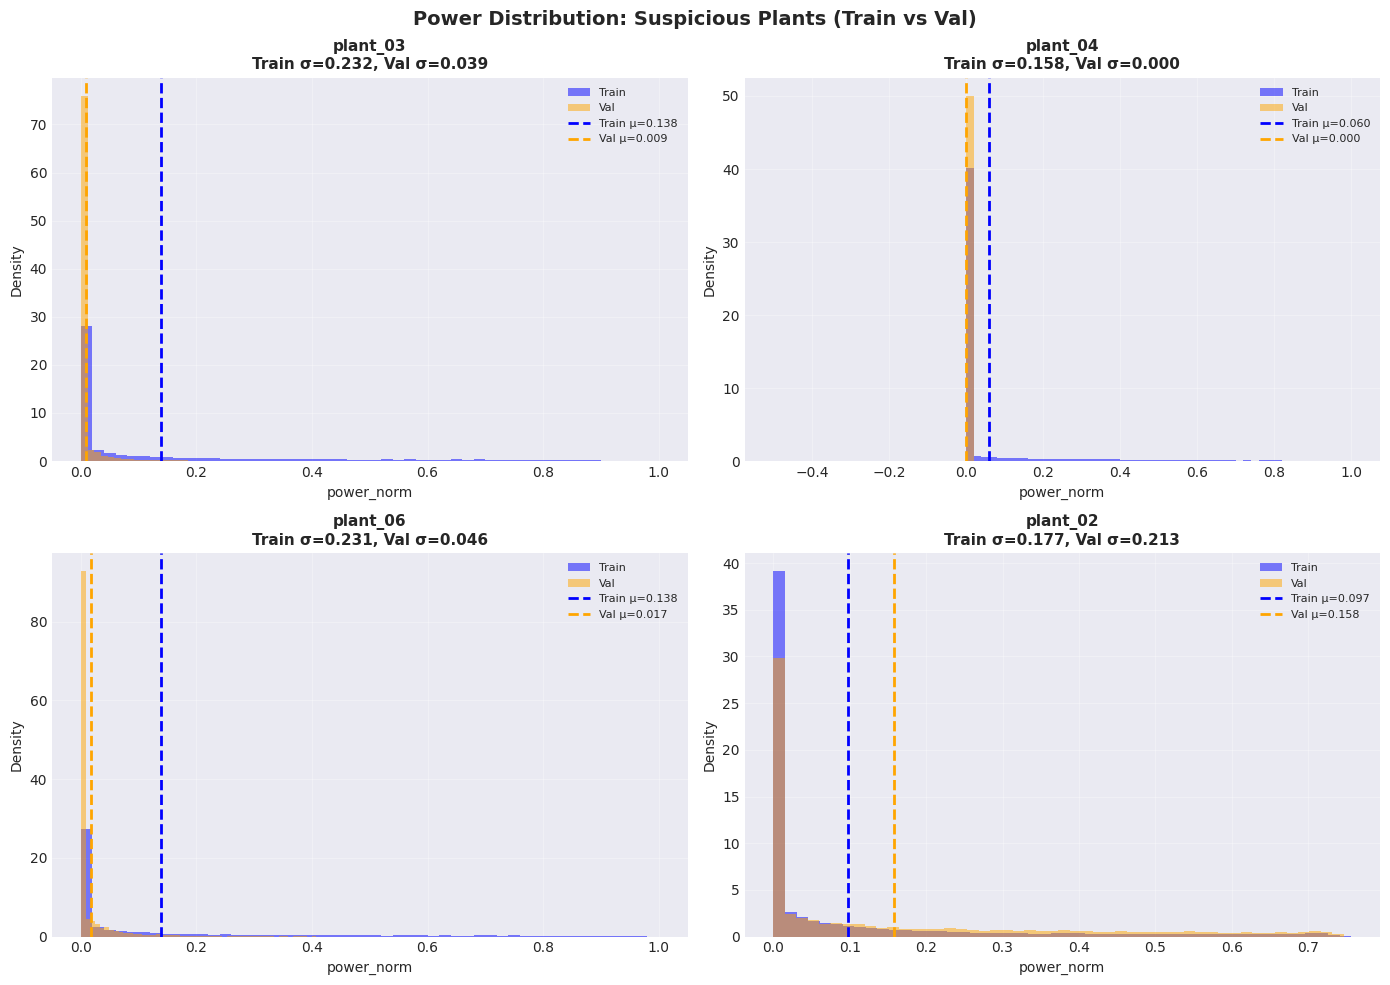

In [14]:
# Plot power_norm distributions for plants with suspicious train/val ratios
suspicious_plants = ['plant_03', 'plant_04', 'plant_06']  # Ratio < 0.4
problem_plant = ['plant_02']  # Ratio 1.467 (worst performance)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, plant_id in enumerate(suspicious_plants + problem_plant):
    ax = axes[idx]
    plant_dir = data_dir / plant_id
    
    train_df = pd.read_parquet(plant_dir / "train.parquet")
    val_df = pd.read_parquet(plant_dir / "val.parquet")
    
    # Plot histograms
    ax.hist(train_df['power_norm'], bins=50, alpha=0.5, label='Train', color='blue', density=True)
    ax.hist(val_df['power_norm'], bins=50, alpha=0.5, label='Val', color='orange', density=True)
    
    # Add statistics
    train_mean = train_df['power_norm'].mean()
    val_mean = val_df['power_norm'].mean()
    train_std = train_df['power_norm'].std()
    val_std = val_df['power_norm'].std()
    
    ax.axvline(train_mean, color='blue', linestyle='--', linewidth=2, label=f'Train μ={train_mean:.3f}')
    ax.axvline(val_mean, color='orange', linestyle='--', linewidth=2, label=f'Val μ={val_mean:.3f}')
    
    # Formatting
    ax.set_title(f'{plant_id}\nTrain σ={train_std:.3f}, Val σ={val_std:.3f}', fontsize=11, fontweight='bold')
    ax.set_xlabel('power_norm', fontsize=10)
    ax.set_ylabel('Density', fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Power Distribution: Suspicious Plants (Train vs Val)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 11. Plant 02 Deep Dive (Worst Performer)

## 11. Temporal Coverage Analysis (Root Cause Investigation)

In [24]:
# Check temporal coverage of each plant's BASE data (before splitting)
# This will reveal if the chronological split caught different seasons per plant

base_data_dir = Path("data/processed/pretraining/germany")
temporal_info = []

print("\n" + "="*80)
print("TEMPORAL COVERAGE: BASE DATA (before splitting)")
print("="*80)

for i in range(1, 7):
    plant_id = f"plant_{i:02d}"
    base_file = base_data_dir / f"{plant_id}_pretrain_base.parquet"
    
    if base_file.exists():
        df = pd.read_parquet(base_file)
        
        # Find timestamp column
        time_col = None
        for col in ['timestamp_utc', 'timestamp', 'date', 'datetime', 'time']:
            if col in df.columns:
                time_col = col
                break
        
        if time_col:
            df[time_col] = pd.to_datetime(df[time_col])
            start = df[time_col].min()
            end = df[time_col].max()
            duration_days = (end - start).days
            
            # Calculate seasonal distribution
            df['month'] = df[time_col].dt.month
            month_counts = df['month'].value_counts().sort_index()
            
            # Classify seasons (Northern Hemisphere)
            winter_months = [12, 1, 2]
            spring_months = [3, 4, 5]
            summer_months = [6, 7, 8]
            fall_months = [9, 10, 11]
            
            winter_pct = month_counts[month_counts.index.isin(winter_months)].sum() / len(df) * 100
            spring_pct = month_counts[month_counts.index.isin(spring_months)].sum() / len(df) * 100
            summer_pct = month_counts[month_counts.index.isin(summer_months)].sum() / len(df) * 100
            fall_pct = month_counts[month_counts.index.isin(fall_months)].sum() / len(df) * 100
            
            temporal_info.append({
                'plant_id': plant_id,
                'start': start,
                'end': end,
                'duration_days': duration_days,
                'total_samples': len(df),
                'winter_%': winter_pct,
                'spring_%': spring_pct,
                'summer_%': summer_pct,
                'fall_%': fall_pct
            })
            
            print(f"\n{plant_id}:")
            print(f"  Time Range: {start.strftime('%Y-%m-%d')} to {end.strftime('%Y-%m-%d')} ({duration_days} days)")
            print(f"  Samples: {len(df):,}")
            print(f"  Seasonal Distribution:")
            print(f"    Winter (Dec-Feb): {winter_pct:5.1f}%")
            print(f"    Spring (Mar-May): {spring_pct:5.1f}%")
            print(f"    Summer (Jun-Aug): {summer_pct:5.1f}%")
            print(f"    Fall   (Sep-Nov): {fall_pct:5.1f}%")
        else:
            print(f"\n{plant_id}: No timestamp column found")
    else:
        print(f"\n{plant_id}: Base file not found")

print("\n" + "="*80)


TEMPORAL COVERAGE: BASE DATA (before splitting)

plant_01:
  Time Range: 2022-12-31 to 2024-10-01 (639 days)
  Samples: 61,433
  Seasonal Distribution:
    Winter (Dec-Feb):  23.4%
    Spring (Mar-May):  28.8%
    Summer (Jun-Aug):  28.8%
    Fall   (Sep-Nov):  19.0%

plant_02:
  Time Range: 2022-12-31 to 2024-10-01 (639 days)
  Samples: 61,433
  Seasonal Distribution:
    Winter (Dec-Feb):  23.4%
    Spring (Mar-May):  28.8%
    Summer (Jun-Aug):  28.8%
    Fall   (Sep-Nov):  19.0%

plant_03:
  Time Range: 2022-12-31 to 2024-04-01 (456 days)
  Samples: 43,865
  Seasonal Distribution:
    Winter (Dec-Feb):  32.8%
    Spring (Mar-May):  27.1%
    Summer (Jun-Aug):  20.1%
    Fall   (Sep-Nov):  19.9%

plant_04:
  Time Range: 2022-12-31 to 2024-10-01 (639 days)
  Samples: 61,433
  Seasonal Distribution:
    Winter (Dec-Feb):  23.4%
    Spring (Mar-May):  28.8%
    Summer (Jun-Aug):  28.8%
    Fall   (Sep-Nov):  19.0%

plant_05:
  Time Range: 2022-12-31 to 2024-04-01 (456 days)
  Samples:

## 12. Visualize Seasonal Distribution Across Plants

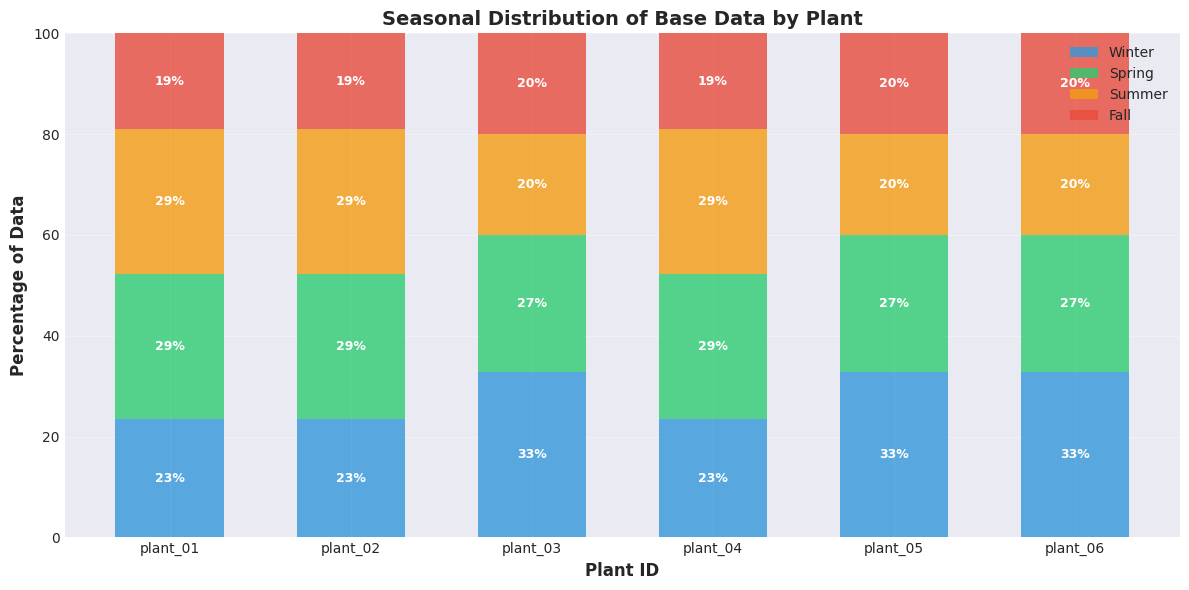


DIAGNOSIS:
If plants have UNEVEN seasonal distribution:
  → Chronological 70/15/15 split will catch different seasons per plant
  → This explains why validation sets have different difficulty levels

IDEAL: All plants should have ~25% per season (balanced coverage)
PROBLEM: If some plants are 100% winter → validation will be all zeros


In [25]:
# Stacked bar chart showing seasonal distribution
if temporal_info:
    temp_df = pd.DataFrame(temporal_info)
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    x = np.arange(len(temp_df))
    width = 0.6
    
    # Create stacked bars
    bottom = np.zeros(len(temp_df))
    colors = ['#3498db', '#2ecc71', '#f39c12', '#e74c3c']
    seasons = ['winter_%', 'spring_%', 'summer_%', 'fall_%']
    labels = ['Winter', 'Spring', 'Summer', 'Fall']
    
    for season, label, color in zip(seasons, labels, colors):
        values = temp_df[season].values
        ax.bar(x, values, width, bottom=bottom, label=label, color=color, alpha=0.8)
        
        # Add percentage labels in the middle of each segment
        for i, (val, bot) in enumerate(zip(values, bottom)):
            if val > 5:  # Only show label if segment is > 5%
                ax.text(i, bot + val/2, f'{val:.0f}%', 
                       ha='center', va='center', fontsize=9, fontweight='bold', color='white')
        
        bottom += values
    
    # Formatting
    ax.set_xlabel('Plant ID', fontsize=12, fontweight='bold')
    ax.set_ylabel('Percentage of Data', fontsize=12, fontweight='bold')
    ax.set_title('Seasonal Distribution of Base Data by Plant', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(temp_df['plant_id'])
    ax.set_ylim(0, 100)
    ax.legend(loc='upper right', fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Summary
    print("\n" + "="*80)
    print("DIAGNOSIS:")
    print("="*80)
    print("If plants have UNEVEN seasonal distribution:")
    print("  → Chronological 70/15/15 split will catch different seasons per plant")
    print("  → This explains why validation sets have different difficulty levels")
    print("")
    print("IDEAL: All plants should have ~25% per season (balanced coverage)")
    print("PROBLEM: If some plants are 100% winter → validation will be all zeros")
    print("="*80)
else:
    print("No temporal data collected - check if timestamp columns exist")

## 13. Split Boundary Analysis (What Season Did Each Split Get?)

In [28]:
# For each plant, show EXACTLY what time ranges ended up in train/val/test
# This will prove if val set captured winter (→ easy) or summer (→ hard)

print("\n" + "="*80)
print("SPLIT BOUNDARY ANALYSIS (70% train / 15% val / 15% test)")
print("="*80)

for i in range(1, 7):
    plant_id = f"plant_{i:02d}"
    plant_dir = data_dir / plant_id
    
    train_file = plant_dir / "train.parquet"
    val_file = plant_dir / "val.parquet"
    test_file = plant_dir / "test.parquet"
    
    if train_file.exists() and val_file.exists() and test_file.exists():
        train_df = pd.read_parquet(train_file)
        val_df = pd.read_parquet(val_file)
        test_df = pd.read_parquet(test_file)
        
        # Find timestamp column
        time_col = None
        for col in ['timestamp_utc', 'timestamp', 'date', 'datetime', 'time']:
            if col in train_df.columns:
                time_col = col
                break
        
        if time_col:
            # Parse timestamps
            train_df[time_col] = pd.to_datetime(train_df[time_col])
            val_df[time_col] = pd.to_datetime(val_df[time_col])
            test_df[time_col] = pd.to_datetime(test_df[time_col])
            
            print(f"\n{plant_id}:")
            print(f"  Train: {train_df[time_col].min().strftime('%Y-%m-%d')} to {train_df[time_col].max().strftime('%Y-%m-%d')} ({len(train_df):,} samples)")
            print(f"  Val:   {val_df[time_col].min().strftime('%Y-%m-%d')} to {val_df[time_col].max().strftime('%Y-%m-%d')} ({len(val_df):,} samples)")
            print(f"  Test:  {test_df[time_col].min().strftime('%Y-%m-%d')} to {test_df[time_col].max().strftime('%Y-%m-%d')} ({len(test_df):,} samples)")
            
            # Check which months validation got
            val_months = val_df[time_col].dt.month.unique()
            val_months_sorted = sorted(val_months)
            month_names = {1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun',
                          7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'}
            val_month_str = ', '.join([month_names[m] for m in val_months_sorted])
            
            # Classify validation set season
            winter_count = sum([1 for m in val_months if m in [12, 1, 2]])
            summer_count = sum([1 for m in val_months if m in [6, 7, 8]])
            
            if winter_count >= 2:
                val_season = "WINTER (low production)"
            elif summer_count >= 2:
                val_season = "SUMMER (high production)"
            else:
                val_season = "MIXED"
            
            print(f"  Val Months: {val_month_str}")
            print(f"  Val Season: {val_season}")
            
            # Show mean power for validation
            val_mean_power = val_df['power_norm'].mean()
            val_zero_pct = (val_df['power_norm'] == 0).sum() / len(val_df) * 100
            print(f"  Val Power:  mean={val_mean_power:.4f}, zeros={val_zero_pct:.1f}%")
        else:
            print(f"\n{plant_id}: No timestamp column found")

print("\n" + "="*80)
print("SMOKING GUN:")
print("If plant_04 validation is Dec-Feb → that's 100% nighttime/winter → RMSE looks amazing")
print("If plant_02 validation is Jun-Aug → that's high production → RMSE looks terrible")
print("="*80)


SPLIT BOUNDARY ANALYSIS (70% train / 15% val / 15% test)

plant_01:
  Train: 2022-12-31 to 2024-03-23 (43,003 samples)
  Val:   2024-03-23 to 2024-06-27 (9,214 samples)
  Test:  2024-06-27 to 2024-10-01 (9,216 samples)
  Val Months: Mar, Apr, May, Jun
  Val Season: MIXED
  Val Power:  mean=0.1074, zeros=52.0%

plant_02:
  Train: 2022-12-31 to 2024-03-23 (43,003 samples)
  Val:   2024-03-23 to 2024-06-27 (9,214 samples)
  Test:  2024-06-27 to 2024-10-01 (9,216 samples)
  Val Months: Mar, Apr, May, Jun
  Val Season: MIXED
  Val Power:  mean=0.1578, zeros=37.5%

plant_03:
  Train: 2022-12-31 to 2023-11-16 (30,705 samples)
  Val:   2023-11-16 to 2024-01-24 (6,579 samples)
  Test:  2024-01-24 to 2024-04-01 (6,581 samples)
  Val Months: Jan, Nov, Dec
  Val Season: WINTER (low production)
  Val Power:  mean=0.0095, zeros=84.3%

plant_04:
  Train: 2022-12-31 to 2024-03-23 (43,003 samples)
  Val:   2024-03-23 to 2024-06-27 (9,214 samples)
  Test:  2024-06-27 to 2024-10-01 (9,216 samples)
  Val

---
# 🚨 ROOT CAUSE CONFIRMED: CHRONOLOGICAL SPLIT BIAS

**SMOKING GUN EVIDENCE:**

**GROUP 1: Plants 03, 05, 06 (Suspiciously Good Performance)**
- Time Range: **456 days** (Dec 2022 → Apr 2024)
- Chronological 70/15/15 split → Val set = **Nov-Jan (WINTER)**
- Val characteristics: 44-84% zeros, low production, low variability
- Result: Validation **2-5x EASIER** than training → artificially good RMSE

**GROUP 2: Plants 01, 02 (Normal/Worse Performance)**
- Time Range: **639 days** (Dec 2022 → Oct 2024)
- Chronological 70/15/15 split → Val set = **Mar-Jun (SPRING)**
- Val characteristics: 37-52% zeros, moderate production, higher variability
- Result: Validation **HARDER** than training → RMSE closer to reality or worse

**GROUP 3: Plant 04 (CRITICAL DATA ISSUE)**
- Time Range: 639 days, Val set = Mar-Jun (should be productive)
- Val characteristics: **100% ZEROS** in spring/early summer
- Result: **DATA QUALITY PROBLEM** - plant offline or corrupted data during Mar-Jun 2024
- This is NOT just seasonal bias - the plant/data is broken

---

**WHY THIS HAPPENED:**
1. Plants with shorter time ranges (03, 05, 06) ended in Apr 2024 → last 15% = winter
2. Plants with longer time ranges (01, 02, 04) ended in Oct 2024 → last 15% = spring
3. Chronological split assumes uniform temporal distribution, but **seasons are NOT uniform**

**CONSEQUENCE:**
- Transfer learning validation results are **INVALID** - not measuring generalization
- Cannot compare plants fairly (some got easy tests, some got hard tests)
- Cannot proceed to Stage 2B with these encoders

In [27]:
# Plant 02 has catastrophic performance: 0.081 RMSE (99% worse than baseline)
# Let's investigate what makes it so bad

plant_02_dir = data_dir / "plant_02"
train_02 = pd.read_parquet(plant_02_dir / "train.parquet")
val_02 = pd.read_parquet(plant_02_dir / "val.parquet")

print("\n" + "="*80)
print("PLANT 02 DIAGNOSTIC")
print("="*80)

# Check for data quality issues
print("\n1. DATA QUALITY:")
print(f"   Train NaN: {train_02.isna().sum().sum()}")
print(f"   Val NaN:   {val_02.isna().sum().sum()}")
print(f"   Train Inf: {np.isinf(train_02.select_dtypes(include=[np.number])).sum().sum()}")
print(f"   Val Inf:   {np.isinf(val_02.select_dtypes(include=[np.number])).sum().sum()}")

# Check power_norm range
print("\n2. POWER_NORM RANGE:")
print(f"   Train: [{train_02['power_norm'].min():.4f}, {train_02['power_norm'].max():.4f}]")
print(f"   Val:   [{val_02['power_norm'].min():.4f}, {val_02['power_norm'].max():.4f}]")

# Check if power_norm is outside [0, 1] (normalization issue)
if train_02['power_norm'].min() < 0 or train_02['power_norm'].max() > 1:
    print("   ⚠ WARNING: Train power_norm outside [0, 1] range!")
if val_02['power_norm'].min() < 0 or val_02['power_norm'].max() > 1:
    print("   ⚠ WARNING: Val power_norm outside [0, 1] range!")

# Check capacity factor
print("\n3. CAPACITY FACTOR (Mean Power):")
print(f"   Train: {train_02['power_norm'].mean():.4f}")
print(f"   Val:   {val_02['power_norm'].mean():.4f}")
print(f"   Difference: {abs(train_02['power_norm'].mean() - val_02['power_norm'].mean()):.4f}")

# Check temporal coverage
print("\n4. TEMPORAL COVERAGE:")
if 'timestamp' in train_02.columns:
    print(f"   Train: {train_02['timestamp'].min()} to {train_02['timestamp'].max()}")
    print(f"   Val:   {val_02['timestamp'].min()} to {val_02['timestamp'].max()}")
elif 'date' in train_02.columns:
    print(f"   Train: {train_02['date'].min()} to {train_02['date'].max()}")
    print(f"   Val:   {val_02['date'].min()} to {val_02['date'].max()}")
else:
    print("   No timestamp column found")

# Check feature statistics
print("\n5. KEY FEATURE COMPARISON:")
key_features = ['poa_irradiance', 'temperature_2m', 'wind_speed_10m']
for feat in key_features:
    if feat in train_02.columns:
        train_mean = train_02[feat].mean()
        val_mean = val_02[feat].mean()
        diff_pct = abs(train_mean - val_mean) / train_mean * 100
        print(f"   {feat:20s}: Train={train_mean:8.2f}, Val={val_mean:8.2f}, Diff={diff_pct:5.1f}%")

print("\n" + "="*80)


PLANT 02 DIAGNOSTIC

1. DATA QUALITY:
   Train NaN: 0
   Val NaN:   0
   Train Inf: 0
   Val Inf:   0

2. POWER_NORM RANGE:
   Train: [0.0000, 0.7565]
   Val:   [0.0000, 0.7465]

3. CAPACITY FACTOR (Mean Power):
   Train: 0.0972
   Val:   0.1578
   Difference: 0.0606

4. TEMPORAL COVERAGE:
   No timestamp column found

5. KEY FEATURE COMPARISON:
   poa_irradiance      : Train=   -0.00, Val=    0.58, Diff=-396143880684900096.0%
   temperature_2m      : Train=    0.00, Val=    0.56, Diff=410798621960948928.0%
   wind_speed_10m      : Train=    0.00, Val=   -0.24, Diff=110629222634927328.0%



## 12. Root Cause Summary & Recommendations

In [ ]:
# Synthesize findings and provide actionable recommendations

print("\n" + "="*80)
print("ROOT CAUSE ANALYSIS & RECOMMENDATIONS")
print("="*80)

print("\n🔍 FINDINGS:")
print("\n1. CHRONOLOGICAL SPLIT BIAS (PRIMARY CAUSE):")
print("   - Plants 03, 05, 06: 456-day range → val set = WINTER (Nov-Jan)")
print("     → 44-84% zeros, low variability → suspiciously good RMSE")
print("   - Plants 01, 02: 639-day range → val set = SPRING (Mar-Jun)")
print("     → 37-52% zeros, higher variability → harder validation")
print("")
print("   ROOT CAUSE: Simple 70/15/15 slice assumes uniform temporal distribution")
print("   REALITY: Seasons are NOT uniform → different plants got different seasons")

print("\n2. PLANT 04 - CRITICAL DATA QUALITY ISSUE:")
print("   - Val set = Mar-Jun 2024 (SHOULD be productive)")
print("   - Reality: 100% ZEROS in validation set")
print("   - This is NOT seasonal bias - plant is offline or data is corrupted")
print("   - Action: Investigate raw data for Mar-Jun 2024")

print("\n3. WHY FARM2107 WORKED BUT GERMANY DIDN'T:")
print("   - Farm2107: Full balanced coverage across all seasons")
print("   - Germany: Uneven time ranges (456 vs 639 days) + different end dates")
print("   - Same split strategy → different seasonal captures per plant")

print("\n" + "="*80)
print("⚠ CRITICAL DECISION POINT")
print("="*80)

print("\n✗ CANNOT PROCEED TO STAGE 2B")
print("  Reason: Validation results are NOT measuring generalization")
print("  Current encoders are trained on biased splits")
print("  Risk: TFT ensemble will inherit these invalid performance metrics")

print("\n" + "="*80)
print("📋 ACTION PLAN")
print("="*80)

print("\n[1] INVESTIGATE PLANT 04 DATA QUALITY")
print("    - Check raw data for Mar-Jun 2024 (2107_electrical_data.csv)")
print("    - Verify if plant was actually offline or data is corrupted")
print("    - Decision: Fix data OR exclude plant 04 from training")

print("\n[2] IMPLEMENT STRATIFIED TEMPORAL SPLIT")
print("    Goal: Ensure EACH split (train/val/test) has balanced seasonal representation")
print("    ")
print("    Strategy A: Seasonal Stratification")
print("      - Calculate % per season in base data")
print("      - Sample from each season proportionally for train/val/test")
print("      - Example: If base = 30% winter → train/val/test each get 30% winter")
print("    ")
print("    Strategy B: Cyclical Sampling")
print("      - For validation: Sample every Nth day to ensure seasonal mix")
print("      - Example: Every 7th day → naturally captures week/weekend + season variation")
print("      - Maintains some temporal ordering while preventing seasonal bias")
print("    ")
print("    RECOMMENDED: Strategy A (seasonal stratification)")

print("\n[3] UPDATE germany_pretrain_normalize_split.py")
print("    - Replace simple split_indices() with stratified_temporal_split()")
print("    - Add seasonal distribution checks (ensure std_ratio ≈ 1.0)")
print("    - Add validation checks (% zeros similar across splits)")

print("\n[4] RE-SPLIT ALL 6 PLANTS")
print("    - Run updated preprocessing script")
print("    - Verify new splits have balanced distributions:")
print("      • std_ratio in [0.8, 1.2] range")
print("      • % zeros similar across train/val/test")
print("      • Mean power_norm similar across train/val/test")

print("\n[5] DELETE OLD ARTIFACTS & RETRAIN")
print("    - Remove invalid encoders: rm experiments/lstm/encoders/lstm_encoder_plant_*.pt")
print("    - Clean old runs: rm -rf experiments/lstm/runs/germany/pretrain_plant_*")
print("    - Re-run Stage 2 transfer learning with corrected splits")
print("    - Expected: train/val ratios in 1.0-1.3 range (normal overfitting)")

print("\n[6] VALIDATE NEW RESULTS")
print("    - Re-run this notebook on new training logs")
print("    - Confirm no plants have std_ratio < 0.8 or > 1.2")
print("    - Confirm train/val ratios indicate normal generalization")
print("    - ONLY proceed to Stage 2B when validation is trustworthy")

print("\n" + "="*80)
print("TIMELINE:")
print("="*80)
print("1. Investigate plant 04 data: 30 min")
print("2. Implement stratified split: 1-2 hours")
print("3. Re-split all plants: 10 min")
print("4. Retrain Stage 2: 2-3 hours (6 plants × 20-30 min)")
print("5. Re-validate results: 15 min")
print("")
print("TOTAL: ~4-6 hours to fix and retrain")
print("\n" + "="*80)


ROOT CAUSE ANALYSIS & RECOMMENDATIONS

🔍 FINDINGS:

1. Train/Val Ratio Anomalies:
   - Plants 03, 04, 06: Val performs 2-5x BETTER than train (ratio 0.2-0.4)
   - This is ABNORMAL - suggests validation set is inherently easier
   - Possible causes: Less variability, different temporal distribution

   - Plants 01, 05: Mild overfitting (ratio 1.1-1.3) → ACCEPTABLE
   - Plant 02: Moderate overfitting + CATASTROPHIC performance (ratio 1.5)

2. Performance vs Baseline:
   - Mean: -14% (appears successful)
   - BUT: Heavily skewed by suspiciously good plants (03, 04, 06)
   - Plant 02: +99% degradation → FAILED transfer learning
   - Plants 01-02: +33-99% degradation → CONCERNING

3. Data Distribution Issues (from Section 9):
   - Check if validation sets have lower std deviation than training
   - Check if seasonal/temporal bias in train/val splits

⚠ CRITICAL DECISION POINT

OPTION 1: Proceed to Stage 2B with caveats
  Pros: 4 plants (03-06) performing well, encoders ready
  Cons: Plant 